In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Load CSV ----
file_path = "Trees.csv"  # change to your file
df = pd.read_csv(file_path)

# ---- 2. Basic dataset overview ----
print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst few rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

# cols_to_keep = ["OBJECTID", "species", "height", "diameter"]

# df = df[cols_to_keep]


Dataset shape:
(55676, 61)

Column names:
Index(['OBJECTID', 'ASSET_ID', 'SITE_NAME', 'PLOT_NO', 'FEATURE_ID',
       'LOCATION', 'TYPE', 'PRIM_MEAS', 'UNIT', 'SITE_CODE', 'FEAT_GP', 'X',
       'Y', 'DEAD', 'CLASSIFICATION', 'EXTENT_EASTING_1', 'EXTENT_NORTHING_1',
       'EXTENT_EASTING_2', 'EXTENT_NORTHING_2', 'LAYERS', 'LATIN_CODE',
       'LATIN_NAME', 'FEATURE_TYPE_NAME', 'COMMON_NAME', 'FULL_COMMON_NAME',
       'CROWN_HEIGHT', 'CROWN_WIDTH', 'CROWN_AREA', 'DBH',
       'LOCATION_RISK_ZONE', 'EPICORMIC', 'INSURANCE_CLAIM_HISTORY',
       'CENTRAL_ASSET_ID', 'CONTRACT_AREA_NAME', 'CUSTOMER', 'DEAD_FLAG',
       'FEATURE_GROUP', 'FEATURE_GROUP_CODE', 'FEATURETYPECODE', 'NOTES',
       'REVISION_NO', 'TREE_SPECIES', 'TREE_MODIFIED_RISK',
       'CANOPY_SIZE_AT_MATURITY', 'SPONSORSHIP', 'SPONSORSHIP_PACKAGE',
       'PLANTING_SEASON', 'PLANTING_FUNDER', 'PLANTING_NOTES', 'SPECIES_NOTES',
       'TREE_TYPE', 'JOBS_REQUIRED', 'SERVICES_VISIBILITY', 'CONSTRAINTS',
       'CANCELLATION

In [21]:
cols = ["CROWN_WIDTH", "CROWN_HEIGHT"]
#print(df[cols])

for col in cols:
    df[col] = (
        df[col]
        .str.extract(r'(\d+\.?\d*)')[0]   # pull out the number
        .astype(float)
    )
print(df[cols])
# df[cols] = df[cols].replace("No Code Allocated", pd.NA)
# df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

       CROWN_WIDTH  CROWN_HEIGHT
0             14.0          15.0
1              NaN           NaN
2              1.0           4.0
3              1.0           4.0
4              NaN           NaN
...            ...           ...
55671          6.0           8.0
55672          7.0           8.0
55673          7.0           8.0
55674          7.0           9.0
55675          7.0           9.0

[55676 rows x 2 columns]



Numeric columns: ['OBJECTID', 'PLOT_NO', 'LOCATION', 'PRIM_MEAS', 'X', 'Y', 'EXTENT_EASTING_1', 'EXTENT_NORTHING_1', 'EXTENT_EASTING_2', 'EXTENT_NORTHING_2', 'FEATURE_TYPE_NAME', 'CROWN_HEIGHT', 'CROWN_WIDTH', 'EPICORMIC', 'CONTRACT_AREA_NAME', 'CUSTOMER', 'FEATURE_GROUP', 'FEATURETYPECODE', 'NOTES', 'REVISION_NO', 'SPONSORSHIP_PACKAGE', 'CONSTRAINTS', 'NOTES_FOR_STATUS']


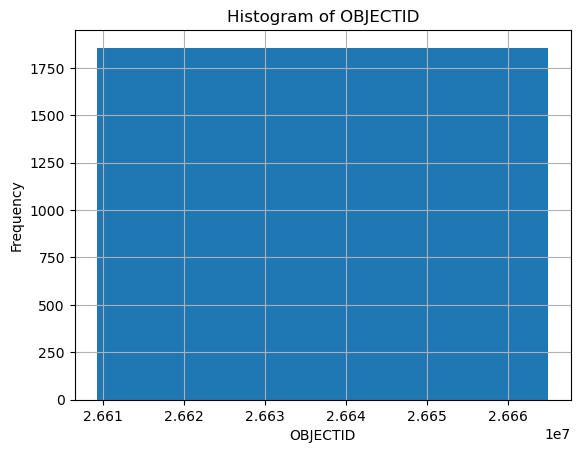

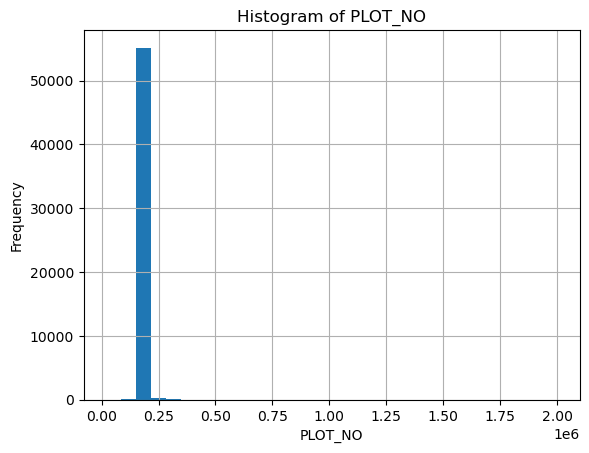

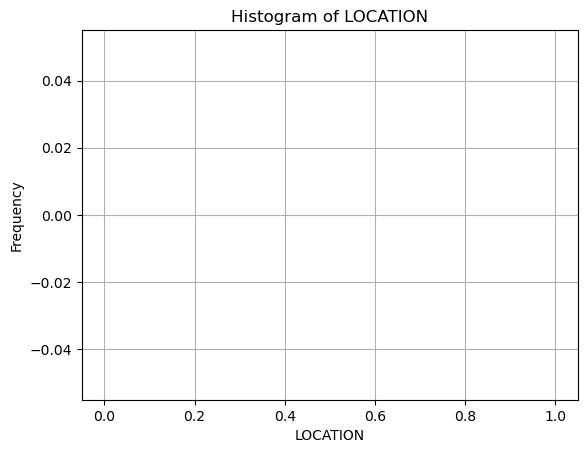

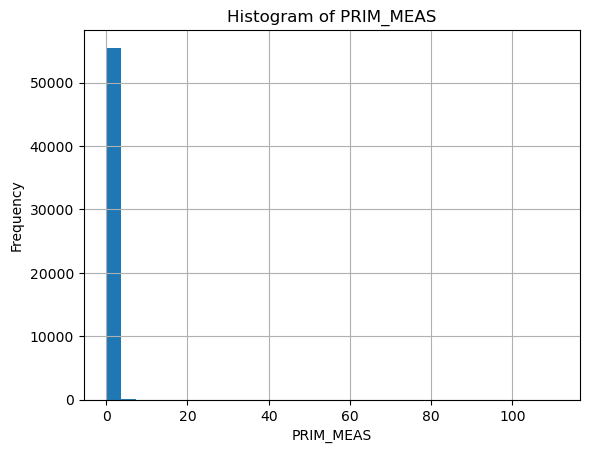

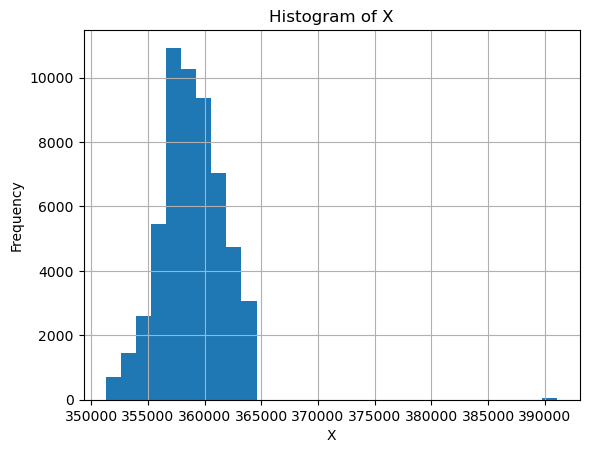

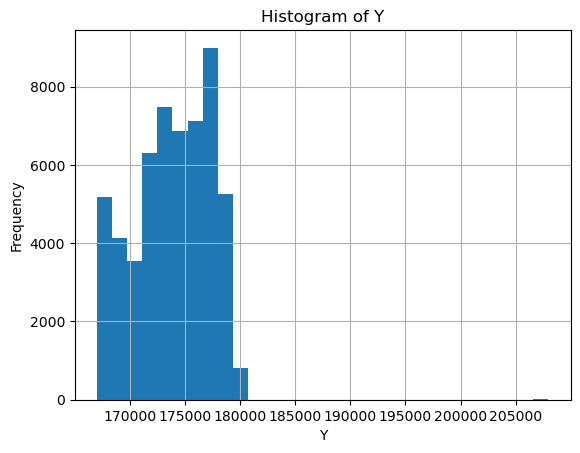

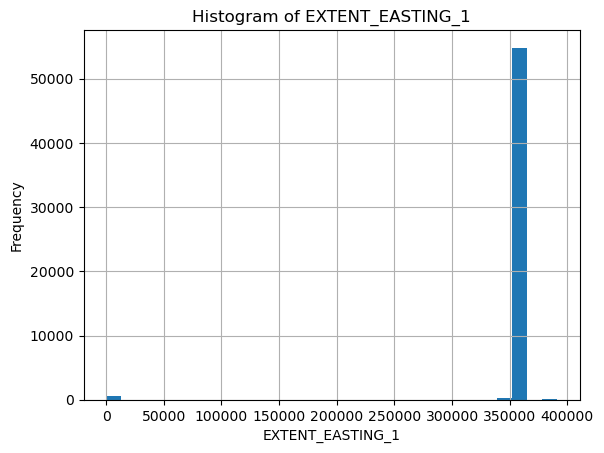

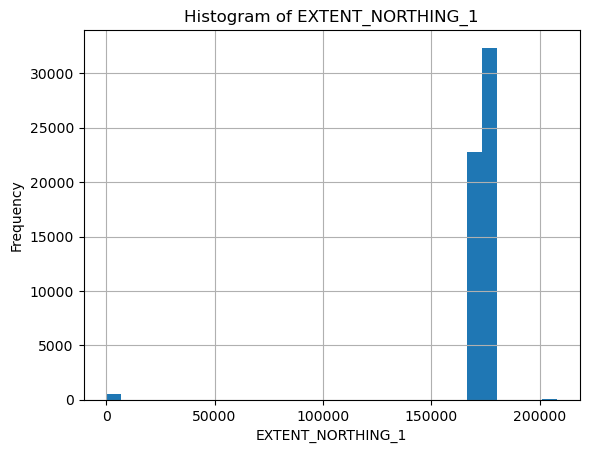

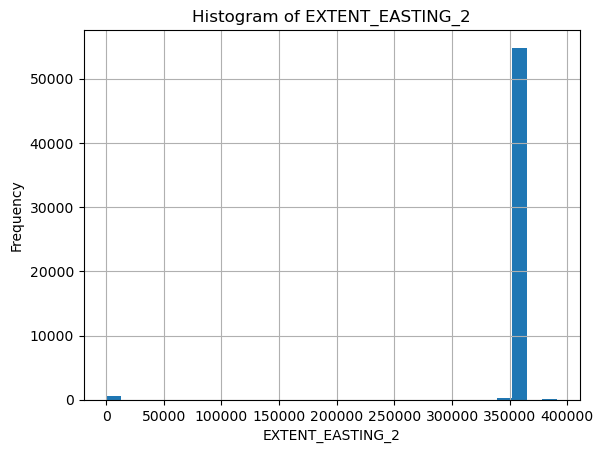

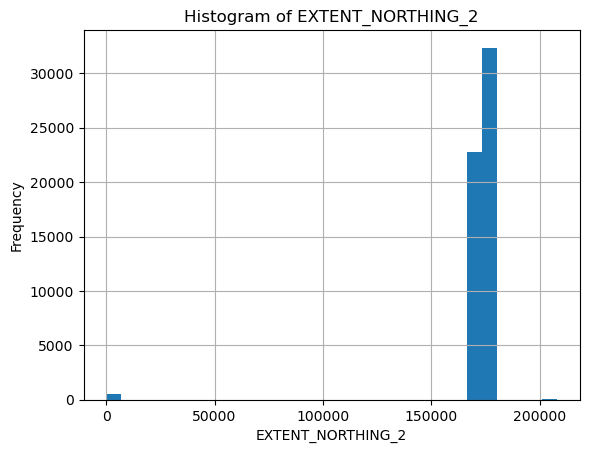

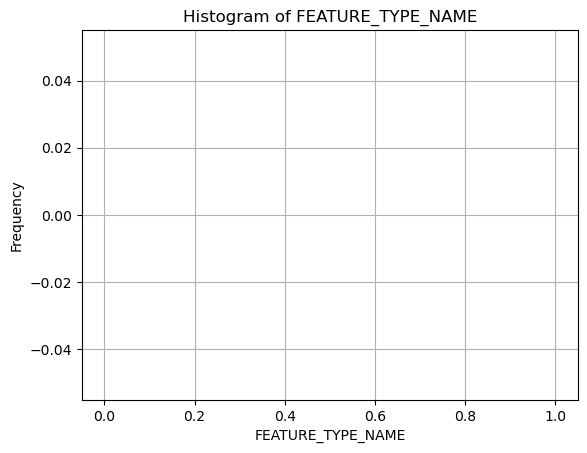

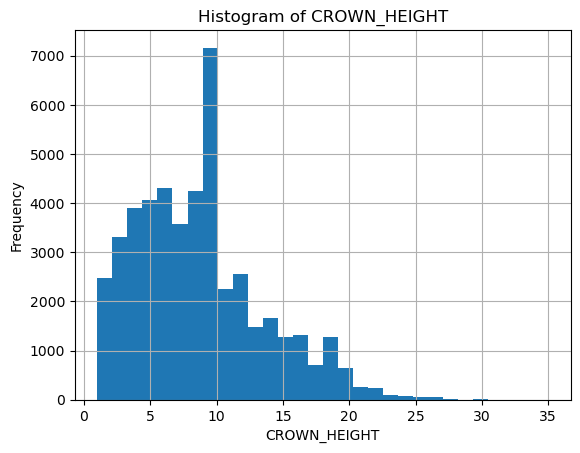

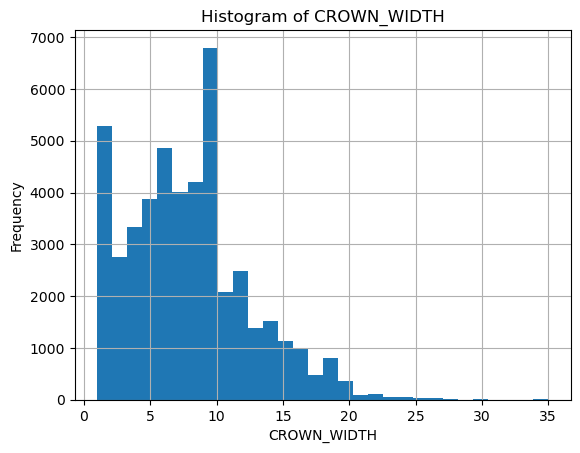

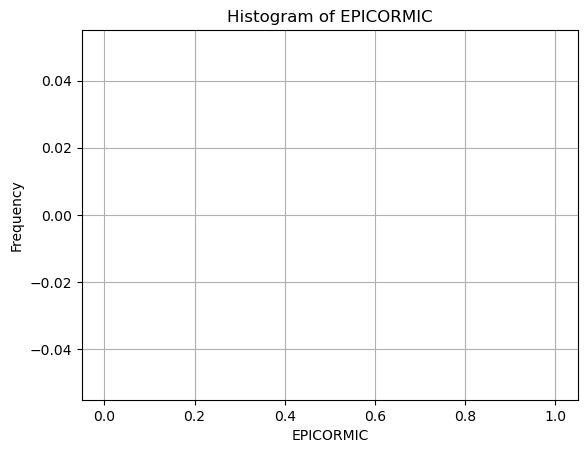

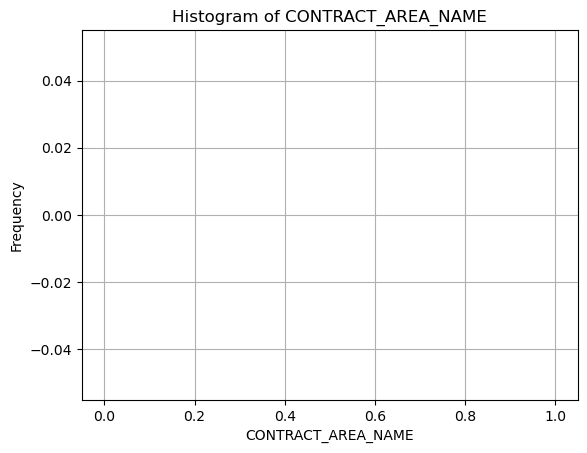

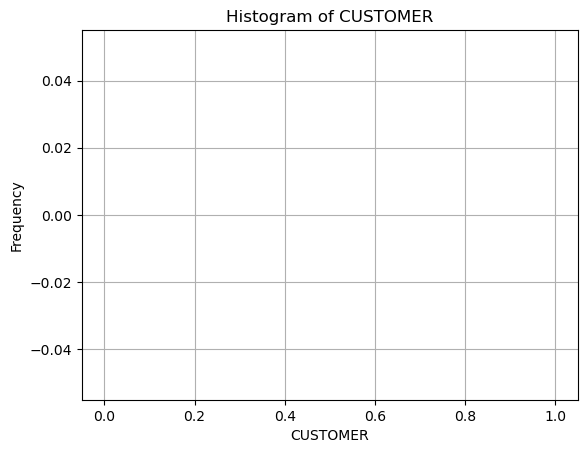

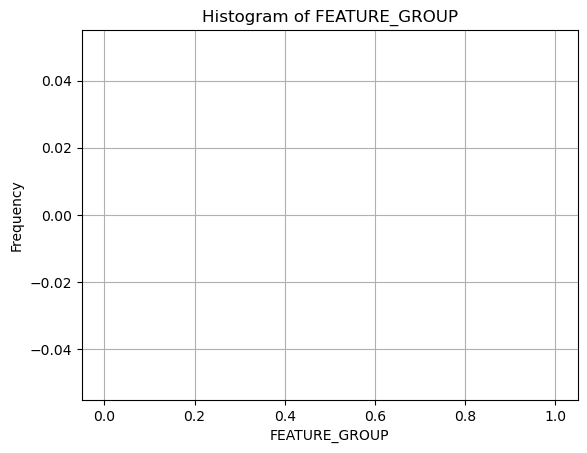

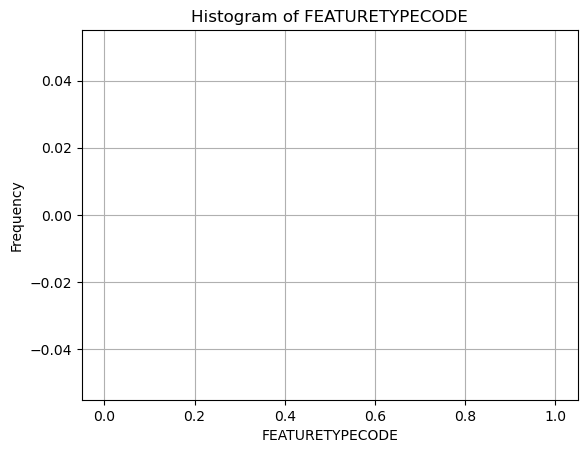

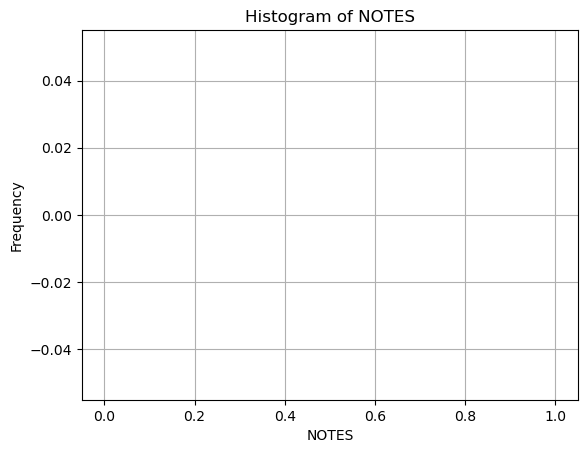

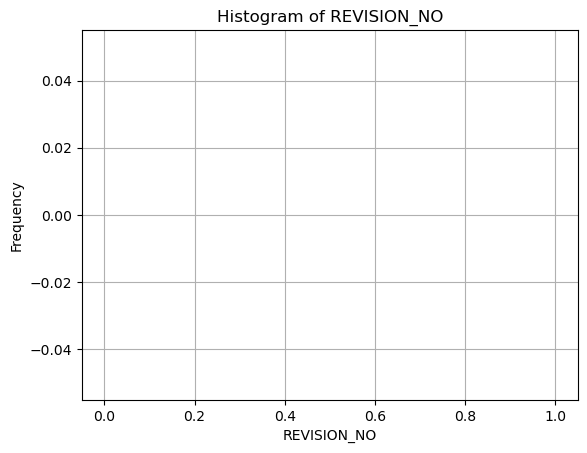

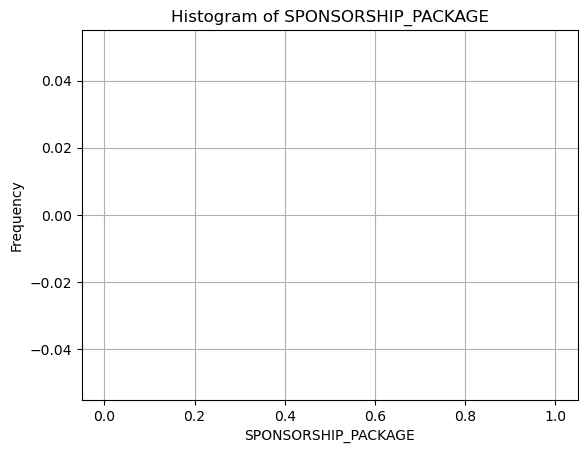

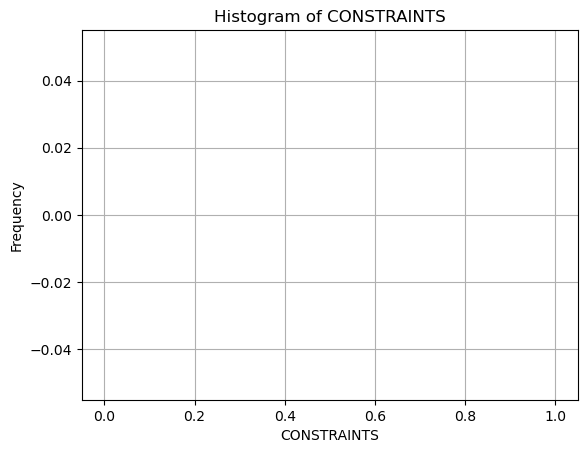

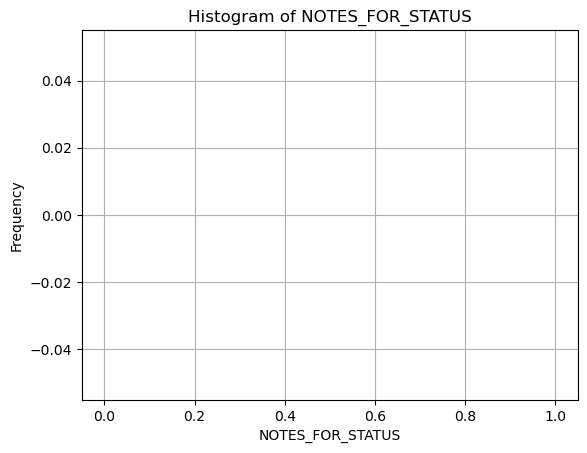


Non-numeric counts per column:
OBJECTID: 0
ASSET_ID: 55676
SITE_NAME: 55676
PLOT_NO: 0
FEATURE_ID: 2914
LOCATION: 0
TYPE: 55676
PRIM_MEAS: 0
UNIT: 55676
SITE_CODE: 55676
FEAT_GP: 55676
X: 0
Y: 0
DEAD: 55676
CLASSIFICATION: 55676
EXTENT_EASTING_1: 0
EXTENT_NORTHING_1: 0
EXTENT_EASTING_2: 0
EXTENT_NORTHING_2: 0
LAYERS: 2914
LATIN_CODE: 55364
LATIN_NAME: 55665
FEATURE_TYPE_NAME: 0
COMMON_NAME: 52099
FULL_COMMON_NAME: 53562
CROWN_HEIGHT: 0
CROWN_WIDTH: 0
CROWN_AREA: 42992
DBH: 55676
LOCATION_RISK_ZONE: 55676
EPICORMIC: 0
INSURANCE_CLAIM_HISTORY: 55676
CENTRAL_ASSET_ID: 55676
CONTRACT_AREA_NAME: 0
CUSTOMER: 0
DEAD_FLAG: 55676
FEATURE_GROUP: 0
FEATURE_GROUP_CODE: 55676
FEATURETYPECODE: 0
NOTES: 0
REVISION_NO: 0
TREE_SPECIES: 55665
TREE_MODIFIED_RISK: 55676
CANOPY_SIZE_AT_MATURITY: 55676
SPONSORSHIP: 36919
SPONSORSHIP_PACKAGE: 0
PLANTING_SEASON: 55676
PLANTING_FUNDER: 55676
PLANTING_NOTES: 1287
SPECIES_NOTES: 800
TREE_TYPE: 55676
JOBS_REQUIRED: 55676
SERVICES_VISIBILITY: 55644
CONSTRAINTS: 0

In [22]:


# ---- 3. Histograms for numeric columns ----
numeric_cols = df.select_dtypes(include="number").columns

print("\nNumeric columns:", list(numeric_cols))

for col in numeric_cols:
    plt.figure()
    df[col].dropna().hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


# ---- 4. Count non-numeric occurrences in each column ----
print("\nNon-numeric counts per column:")

for col in df.columns:
    non_numeric = df[col].apply(lambda x: not pd.api.types.is_number(x))
    count = non_numeric.sum()
    print(f"{col}: {count}")


# ---- 5. Value counts for categorical columns ----
cat_cols = df.select_dtypes(include="object").columns

print("\nCategorical value counts:")

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(20))